# 问题二：FILT. NTU 自历史项 + 截断到 2 的 ARX 模型

本 notebook 是第二问的一个干净版本，只加入两件事：

```text
1. FILT. NTU 自身历史项
2. FILT. NTU 上限截断到 2
```

不加入：

```text
rolling features
auxiliary variables
residual correction
dynamic response function
GRU / LSTM
SHAP
大规模 GridSearch
```

---

## 建模目的

原始第二问需要建立动态模型，描述：

```text
R/W NTU
R/W PH
ALUM
F/RIDE
R/W FLOW
```

对：

```text
FILT. NTU
```

的时滞影响。

本 notebook 在 selected-lag 外生变量模型基础上，额外加入：

```text
FILT. NTU_lag1
FILT. NTU_lag2
FILT. NTU_lag3
```

用于刻画滤后水浊度的动态惯性。

同时对目标变量进行截断：

```text
FILT. NTU_clip2 = min(FILT. NTU, 2)
```

也就是说，所有大于 2 的 `FILT. NTU` 都映射为 2。

---

## 模型对比

本 notebook 会比较三类模型：

```text
A. SelectedLag_Clip2
   只使用外生变量 selected lag

B. HistoryOnly_Clip2
   只使用 FILT. NTU 自身历史项

C. ARX_Clip2
   FILT. NTU 自身历史项 + 外生变量 selected lag
```

其中最终最推荐关注：

```text
ARX_Clip2 + Ridge
```

---

## 输出目录

```text
outputs/problem2_arx_clip2/
```

重点输出文件：

```text
problem2_arx_clip2_model_results.xlsx
problem2_arx_clip2_test_predictions.xlsx
problem2_arx_clip2_selected_lag_summary.xlsx
problem2_arx_clip2_coefficients.xlsx
problem2_arx_clip2_final_summary.xlsx
figures/
models/
```


## 1. 导入依赖库

为了兼容旧版 scikit-learn，RMSE 使用：

```python
np.sqrt(mean_squared_error(y_true, y_pred))
```


In [1]:
from pathlib import Path
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    from xgboost import XGBRegressor
    XGB_AVAILABLE = True
except Exception as e:
    XGB_AVAILABLE = False
    XGB_IMPORT_ERROR = e

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 240)

print("XGBoost available:", XGB_AVAILABLE)
if not XGB_AVAILABLE:
    print("XGBoost import error:", XGB_IMPORT_ERROR)


XGBoost available: True


## 2. 参数设置

目标变量：

```text
FILT. NTU
```

核心外生变量：

```text
R/W NTU
R/W PH
ALUM
F/RIDE
R/W FLOW
```

新增自历史项：

```text
FILT. NTU_lag1
FILT. NTU_lag2
FILT. NTU_lag3
```

目标截断：

```text
FILT. NTU > 2 → 2
```


In [2]:
TARGET_COL = "FILT. NTU"
CLIPPED_TARGET_COL = "FILT. NTU_clip2"

OUTPUT_DIR_NAME = "problem2_arx_clip2"

RANDOM_STATE = 42
TRAIN_RATIO = 0.70
RECORD_INTERVAL_HOURS = 2

# 截断上限
TARGET_CLIP_UPPER = 2.0

# 自历史项：过去 2h、4h、6h
TARGET_AR_LAGS = [1, 2, 3]

# 第二问核心外生变量
CORE_VARS = [
    "R/W NTU",
    "R/W PH",
    "ALUM",
    "F/RIDE",
    "R/W FLOW",
]

# 外生变量 selected lag 搜索范围
DEFAULT_LAG_GRID = list(range(0, 7))  # lag0-lag6，对应 0-12h
ALUM_LAG_GRID = list(range(1, 7))     # ALUM 从 lag1 开始，避免过度强调即时投药

print("参数设置完成。")


参数设置完成。


## 3. 自动定位 `merged.xlsx`

本 notebook 从原始 `merged.xlsx` 读取。  
不依赖之前 P2 的任何中间结果。


In [3]:
def locate_merged_file(filename="merged.xlsx"):
    cwd = Path.cwd().resolve()
    candidates = []

    search_roots = [cwd] + list(cwd.parents)

    for root in search_roots:
        candidates.extend([
            root / "data" / filename,
            root / "codes" / "data" / filename,
            root / "2026-Asia-Pacific-cup" / "data" / filename,
            root / "2026-Asia-Pasific-cup" / "data" / filename,
            root / filename,
        ])

    seen = set()
    unique_candidates = []

    for p in candidates:
        p = p.resolve()
        if p not in seen:
            seen.add(p)
            unique_candidates.append(p)

    for p in unique_candidates:
        if p.exists():
            return p

    for p in cwd.rglob(filename):
        return p.resolve()

    for parent in cwd.parents:
        try:
            for p in parent.rglob(filename):
                return p.resolve()
        except Exception:
            pass

    searched = "\n".join(str(p) for p in unique_candidates)
    raise FileNotFoundError(f"未找到 {filename}。已检查路径：\n{searched}")


DATA_PATH = locate_merged_file()
DATA_DIR = DATA_PATH.parent

if DATA_DIR.name == "data":
    PROJECT_DIR = DATA_DIR.parent
else:
    PROJECT_DIR = DATA_DIR

OUTPUT_DIR = PROJECT_DIR / "outputs" / OUTPUT_DIR_NAME
FIG_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("当前工作目录：", Path.cwd().resolve())
print("使用数据文件：", DATA_PATH)
print("输出目录：", OUTPUT_DIR)


当前工作目录： E:\桌面\亚太杯\2026-Asia-Pasific-cup\codes
使用数据文件： E:\桌面\亚太杯\2026-Asia-Pasific-cup\data\merged.xlsx
输出目录： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_arx_clip2


## 4. 读取数据并构造时间列

构造：

```text
DATETIME
OP_DATE
```

`OP_DATE` 采用前面问题一致的运行日定义：

```text
07:00 至次日 05:00 归为同一个运行日。
```


In [4]:
df = pd.read_excel(DATA_PATH)

print("原始数据规模：", df.shape)
print("原始列名：")
print(df.columns.tolist())

if TARGET_COL not in df.columns:
    raise ValueError(f"未找到目标变量 {TARGET_COL}。请检查 merged.xlsx。")


def construct_datetime(data):
    data = data.copy()

    if "DATETIME" in data.columns:
        data["DATETIME"] = pd.to_datetime(data["DATETIME"], errors="coerce")
        return data

    date_candidates = ["DATE", "Date", "date"]
    time_candidates = ["TIME", "Time", "time"]

    date_col = next((c for c in date_candidates if c in data.columns), None)
    time_col = next((c for c in time_candidates if c in data.columns), None)

    if date_col is None or time_col is None:
        raise ValueError("无法构造 DATETIME：需要 DATE 和 TIME 两列，或已有 DATETIME 列。")

    date_text = data[date_col].astype(str).str.split().str[0]
    time_text = data[time_col].astype(str).str.split().str[-1]

    data["DATETIME"] = pd.to_datetime(
        date_text + " " + time_text,
        errors="coerce",
    )

    return data


df = construct_datetime(df)
df = df.dropna(subset=["DATETIME"]).sort_values("DATETIME").reset_index(drop=True)

df["OP_DATE"] = df["DATETIME"].dt.date
mask_before_7 = df["DATETIME"].dt.hour < 7
df.loc[mask_before_7, "OP_DATE"] = (
    df.loc[mask_before_7, "DATETIME"] - pd.Timedelta(days=1)
).dt.date

print("时间范围：", df["DATETIME"].min(), "至", df["DATETIME"].max())
display(df[["DATETIME", "OP_DATE", TARGET_COL]].head(15))


原始数据规模： (5460, 18)
原始列名：
['DATE', 'TIME', 'RIVER LEVEL', 'R/W PUMP DUTY', 'R/W FLOW', 'R/W NTU', 'R/W CLR', 'R/W PH', 'FILT. NTU', 'C/W WELL LEVEL', 'PH', 'NTU', 'CLR', 'CL2', 'F/RIDE', 'ALUM', 'T/W PUMP DUTY', 'T/W FLOW']
时间范围： 2025-01-01 07:00:00 至 2026-04-01 05:00:00


,DATETIME,OP_DATE,FILT. NTU
0,2025-01-01 07:00:00,2025-01-01,0.04
1,2025-01-01 09:00:00,2025-01-01,0.05
2,2025-01-01 11:00:00,2025-01-01,0.05
3,2025-01-01 13:00:00,2025-01-01,0.05
4,2025-01-01 15:00:00,2025-01-01,0.05
5,2025-01-01 17:00:00,2025-01-01,0.06
6,2025-01-01 19:00:00,2025-01-01,0.05
7,2025-01-01 21:00:00,2025-01-01,0.05
8,2025-01-01 23:00:00,2025-01-01,0.05
9,2025-01-02 01:00:00,2025-01-01,0.05


## 5. 数据清洗和 FILT. NTU 截断到 2

关键处理：

```text
FILT. NTU_clip2 = min(FILT. NTU, 2)
```

后续所有目标和自历史项都基于 `FILT. NTU_clip2` 构造。

注意：

```text
这里只截断 FILT. NTU；
不截断 R/W NTU、R/W PH、ALUM、F/RIDE、R/W FLOW。
```


In [5]:
# 数值化目标和核心外生变量
for col in [TARGET_COL] + CORE_VARS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# F/RIDE 缺失填 0
if "F/RIDE" in df.columns:
    before_missing = int(df["F/RIDE"].isna().sum())
    df["F/RIDE"] = df["F/RIDE"].fillna(0)
    after_missing = int(df["F/RIDE"].isna().sum())
    print(f"F/RIDE 缺失填 0：before={before_missing}, after={after_missing}")

# 截断目标 FILT. NTU
df[CLIPPED_TARGET_COL] = df[TARGET_COL].clip(upper=TARGET_CLIP_UPPER)

clip_audit = pd.DataFrame([
    {
        "item": "original_max",
        "value": df[TARGET_COL].max(skipna=True),
    },
    {
        "item": "clipped_max",
        "value": df[CLIPPED_TARGET_COL].max(skipna=True),
    },
    {
        "item": "count_above_2_before_clipping",
        "value": int((df[TARGET_COL] > TARGET_CLIP_UPPER).sum()),
    },
    {
        "item": "count_equal_2_after_clipping",
        "value": int((df[CLIPPED_TARGET_COL] == TARGET_CLIP_UPPER).sum()),
    },
    {
        "item": "clip_upper",
        "value": TARGET_CLIP_UPPER,
    },
])

clip_audit_path = OUTPUT_DIR / "problem2_arx_clip2_clip_audit.xlsx"
clip_audit.to_excel(clip_audit_path, index=False)

available_vars = [v for v in CORE_VARS if v in df.columns]
missing_vars = [v for v in CORE_VARS if v not in df.columns]

print("可用核心变量：", available_vars)
print("缺失核心变量：", missing_vars)
print("截断审计表已保存：", clip_audit_path)

print("\n原始 FILT. NTU 描述统计：")
display(df[TARGET_COL].describe())

print("\n截断后 FILT. NTU_clip2 描述统计：")
display(df[CLIPPED_TARGET_COL].describe())

display(clip_audit)


F/RIDE 缺失填 0：before=0, after=0
可用核心变量： ['R/W NTU', 'R/W PH', 'ALUM', 'F/RIDE', 'R/W FLOW']
缺失核心变量： []
截断审计表已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_arx_clip2\problem2_arx_clip2_clip_audit.xlsx

原始 FILT. NTU 描述统计：


count    5460.000000
mean        0.190306
std         0.578003
min         0.020000
25%         0.040000
50%         0.060000
75%         0.110000
max         9.800000
Name: FILT. NTU, dtype: float64


截断后 FILT. NTU_clip2 描述统计：


count    5460.000000
mean        0.158245
std         0.316510
min         0.020000
25%         0.040000
50%         0.060000
75%         0.110000
max         2.000000
Name: FILT. NTU_clip2, dtype: float64

,item,value
0,original_max,9.8
1,clipped_max,2.0
2,count_above_2_before_clipping,89.0
3,count_equal_2_after_clipping,91.0
4,clip_upper,2.0


## 6. 数据审计

输出：

```text
problem2_arx_clip2_data_audit.xlsx
```


In [6]:
base_cols = ["DATETIME", "OP_DATE", TARGET_COL, CLIPPED_TARGET_COL] + available_vars
base_cols = list(dict.fromkeys([c for c in base_cols if c in df.columns]))

base_df = df[base_cols].copy()
base_df = base_df.dropna(subset=["DATETIME", CLIPPED_TARGET_COL]).sort_values("DATETIME").reset_index(drop=True)

audit_df = pd.DataFrame({
    "column": base_cols,
    "dtype": [str(base_df[c].dtype) for c in base_cols],
    "missing_count": [int(base_df[c].isna().sum()) for c in base_cols],
    "missing_rate": [float(base_df[c].isna().mean()) for c in base_cols],
    "unique_count": [int(base_df[c].nunique(dropna=True)) for c in base_cols],
})

audit_path = OUTPUT_DIR / "problem2_arx_clip2_data_audit.xlsx"
audit_df.to_excel(audit_path, index=False)

print("建模基础数据规模：", base_df.shape)
print("数据审计表已保存：", audit_path)
display(audit_df)


建模基础数据规模： (5460, 9)
数据审计表已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_arx_clip2\problem2_arx_clip2_data_audit.xlsx


,column,dtype,missing_count,missing_rate,unique_count
0,DATETIME,datetime64[us],0,0.000000,5460
1,OP_DATE,object,0,0.000000,455
2,FILT. NTU,float64,0,0.000000,210
3,FILT. NTU_clip2,float64,0,0.000000,138
4,R/W NTU,int64,0,0.000000,239
5,R/W PH,float64,1644,0.301099,3
6,ALUM,float64,1644,0.301099,5
7,F/RIDE,float64,0,0.000000,17
8,R/W FLOW,float64,0,0.000000,182


## 7. 构造自历史项和外生变量 lag 特征

构造两类特征：

### A. 自历史项

```text
FILT. NTU_clip2_lag1
FILT. NTU_clip2_lag2
FILT. NTU_clip2_lag3
```

### B. 外生变量候选 lag

```text
R/W NTU_lag0-lag6
R/W PH_lag0-lag6
ALUM_lag1-lag6
F/RIDE_lag0-lag6
R/W FLOW_lag0-lag6
```

后面会只在训练集上选择每个外生变量的最佳 lag。


In [7]:
feature_df = base_df.copy().sort_values("DATETIME").reset_index(drop=True)

created_feature_records = []

# 自历史项：基于 clipped target
target_ar_features = []

for lag in TARGET_AR_LAGS:
    col_name = f"{CLIPPED_TARGET_COL}_lag{lag}"
    feature_df[col_name] = feature_df[CLIPPED_TARGET_COL].shift(lag)
    target_ar_features.append(col_name)

    created_feature_records.append({
        "feature": col_name,
        "source_variable": CLIPPED_TARGET_COL,
        "feature_type": "target_self_history_lag",
        "lag": lag,
        "lag_hours": lag * RECORD_INTERVAL_HOURS,
    })

# 外生变量候选 lag
exog_lag_features_by_var = {}
all_exog_lag_features = []

for var in available_vars:
    if var == "ALUM":
        lag_grid = ALUM_LAG_GRID
    else:
        lag_grid = DEFAULT_LAG_GRID

    exog_lag_features_by_var[var] = []

    for lag in lag_grid:
        col_name = f"{var}_lag{lag}"
        feature_df[col_name] = feature_df[var].shift(lag)
        exog_lag_features_by_var[var].append(col_name)
        all_exog_lag_features.append(col_name)

        created_feature_records.append({
            "feature": col_name,
            "source_variable": var,
            "feature_type": "exogenous_candidate_lag",
            "lag": lag,
            "lag_hours": lag * RECORD_INTERVAL_HOURS,
        })

feature_summary_df = pd.DataFrame(created_feature_records)
feature_summary_path = OUTPUT_DIR / "problem2_arx_clip2_feature_summary.xlsx"
feature_summary_df.to_excel(feature_summary_path, index=False)

print("自历史项：", target_ar_features)
print("外生候选 lag 特征数：", len(all_exog_lag_features))
print("特征说明表已保存：", feature_summary_path)
display(feature_summary_df.head(30))


自历史项： ['FILT. NTU_clip2_lag1', 'FILT. NTU_clip2_lag2', 'FILT. NTU_clip2_lag3']
外生候选 lag 特征数： 34
特征说明表已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_arx_clip2\problem2_arx_clip2_feature_summary.xlsx


,feature,source_variable,feature_type,lag,lag_hours
0,FILT. NTU_clip2_lag1,FILT. NTU_clip2,target_self_history_lag,1,2
1,FILT. NTU_clip2_lag2,FILT. NTU_clip2,target_self_history_lag,2,4
2,FILT. NTU_clip2_lag3,FILT. NTU_clip2,target_self_history_lag,3,6
3,R/W NTU_lag0,R/W NTU,exogenous_candidate_lag,0,0
4,R/W NTU_lag1,R/W NTU,exogenous_candidate_lag,1,2
5,R/W NTU_lag2,R/W NTU,exogenous_candidate_lag,2,4
6,R/W NTU_lag3,R/W NTU,exogenous_candidate_lag,3,6
7,R/W NTU_lag4,R/W NTU,exogenous_candidate_lag,4,8
8,R/W NTU_lag5,R/W NTU,exogenous_candidate_lag,5,10
9,R/W NTU_lag6,R/W NTU,exogenous_candidate_lag,6,12


## 8. 统一 train/test split

所有模型使用同一个时间顺序划分：

```text
前 70% train
后 30% test
```

selected lag 只在训练集上选择，避免测试集信息泄漏。


In [8]:
initial_cols = ["DATETIME", "OP_DATE", CLIPPED_TARGET_COL] + target_ar_features + all_exog_lag_features
split_data = feature_df[initial_cols].copy()
split_data = split_data.rename(columns={CLIPPED_TARGET_COL: "target_FILT_NTU_clip2"})
split_data = split_data.dropna(subset=["DATETIME", "target_FILT_NTU_clip2"]).sort_values("DATETIME").reset_index(drop=True)

n = len(split_data)
split_idx = int(n * TRAIN_RATIO)

train_split_df = split_data.iloc[:split_idx].copy()
test_split_df = split_data.iloc[split_idx:].copy()

print("总样本数：", n)
print("训练集：", train_split_df.shape, train_split_df["DATETIME"].min(), "至", train_split_df["DATETIME"].max())
print("测试集：", test_split_df.shape, test_split_df["DATETIME"].min(), "至", test_split_df["DATETIME"].max())


总样本数： 5460
训练集： (3821, 40) 2025-01-01 07:00:00 至 2025-11-15 15:00:00
测试集： (1639, 40) 2025-11-15 17:00:00 至 2026-04-01 05:00:00


## 9. 在训练集上选择外生变量最佳 lag

选择方式：

```text
best_lag = argmax |Spearman correlation|
```

也就是用训练集上每个 lag 特征与 `target_FILT_NTU_clip2` 的 Spearman 相关性绝对值选择最佳 lag。

输出：

```text
problem2_arx_clip2_selected_lag_summary.xlsx
```


In [9]:
selected_lag_records = []
selected_exog_features = []

for var, lag_cols in exog_lag_features_by_var.items():
    best_record = None

    for col in lag_cols:
        temp = train_split_df[[col, "target_FILT_NTU_clip2"]].copy()
        temp[col] = pd.to_numeric(temp[col], errors="coerce")
        temp["target_FILT_NTU_clip2"] = pd.to_numeric(temp["target_FILT_NTU_clip2"], errors="coerce")
        temp = temp.dropna()

        if len(temp) < 10:
            corr_spearman = np.nan
            corr_pearson = np.nan
        else:
            corr_spearman = temp[col].corr(temp["target_FILT_NTU_clip2"], method="spearman")
            corr_pearson = temp[col].corr(temp["target_FILT_NTU_clip2"], method="pearson")

        lag_num = int(col.split("_lag")[-1])

        record = {
            "variable": var,
            "selected_feature_candidate": col,
            "lag": lag_num,
            "lag_hours": lag_num * RECORD_INTERVAL_HOURS,
            "train_spearman_corr": corr_spearman,
            "train_pearson_corr": corr_pearson,
            "abs_train_spearman_corr": abs(corr_spearman) if pd.notna(corr_spearman) else np.nan,
        }

        if best_record is None:
            best_record = record
        else:
            current_score = record["abs_train_spearman_corr"]
            best_score = best_record["abs_train_spearman_corr"]

            if pd.notna(current_score) and (pd.isna(best_score) or current_score > best_score):
                best_record = record

    selected_lag_records.append(best_record)
    selected_exog_features.append(best_record["selected_feature_candidate"])

selected_lag_df = pd.DataFrame(selected_lag_records)
selected_lag_path = OUTPUT_DIR / "problem2_arx_clip2_selected_lag_summary.xlsx"
selected_lag_df.to_excel(selected_lag_path, index=False)

print("selected lag summary 已保存：", selected_lag_path)
display(selected_lag_df)


selected lag summary 已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_arx_clip2\problem2_arx_clip2_selected_lag_summary.xlsx


,variable,selected_feature_candidate,lag,lag_hours,train_spearman_corr,train_pearson_corr,abs_train_spearman_corr
0,R/W NTU,R/W NTU_lag6,6,12,0.105090,0.167178,0.105090
1,R/W PH,R/W PH_lag0,0,0,-0.025638,-0.028072,0.025638
2,ALUM,ALUM_lag6,6,12,0.073577,-0.008996,0.073577
3,F/RIDE,F/RIDE_lag0,0,0,-0.193778,-0.016177,0.193778
4,R/W FLOW,R/W FLOW_lag6,6,12,0.136858,0.109415,0.136858


## 10. 构造三类模型特征集

比较三组：

```text
SelectedLag_Clip2:
只使用外生变量 selected lag

HistoryOnly_Clip2:
只使用 FILT. NTU_clip2_lag1-lag3

ARX_Clip2:
FILT. NTU_clip2_lag1-lag3 + 外生变量 selected lag
```


In [10]:
selected_lag_features = list(dict.fromkeys(selected_exog_features))
history_only_features = list(dict.fromkeys(target_ar_features))
arx_features = list(dict.fromkeys(target_ar_features + selected_exog_features))

feature_sets = {
    "SelectedLag_Clip2": selected_lag_features,
    "HistoryOnly_Clip2": history_only_features,
    "ARX_Clip2": arx_features,
}

all_features = list(dict.fromkeys(selected_lag_features + history_only_features + arx_features))

model_data = feature_df[["DATETIME", "OP_DATE", TARGET_COL, CLIPPED_TARGET_COL] + all_features].copy()
model_data = model_data.rename(columns={CLIPPED_TARGET_COL: "target_FILT_NTU_clip2"})
model_data = model_data.dropna(subset=["DATETIME", "target_FILT_NTU_clip2"]).sort_values("DATETIME").reset_index(drop=True)

n_model = len(model_data)
split_idx_model = int(n_model * TRAIN_RATIO)

train_df = model_data.iloc[:split_idx_model].copy()
test_df = model_data.iloc[split_idx_model:].copy()

y_train = train_df["target_FILT_NTU_clip2"].values
y_test = test_df["target_FILT_NTU_clip2"].values

feature_set_records = []
for feature_set_name, features in feature_sets.items():
    for feature in features:
        feature_set_records.append({
            "feature_set": feature_set_name,
            "feature": feature,
        })

feature_set_df = pd.DataFrame(feature_set_records)

model_data_path = OUTPUT_DIR / "problem2_arx_clip2_model_data.xlsx"
feature_sets_path = OUTPUT_DIR / "problem2_arx_clip2_feature_sets.xlsx"

model_data.to_excel(model_data_path, index=False)
feature_set_df.to_excel(feature_sets_path, index=False)

print("建模数据已保存：", model_data_path)
print("特征集说明已保存：", feature_sets_path)

for name, features in feature_sets.items():
    print(name, len(features), features)

print("\n最终训练集：", train_df.shape, train_df["DATETIME"].min(), "至", train_df["DATETIME"].max())
print("最终测试集：", test_df.shape, test_df["DATETIME"].min(), "至", test_df["DATETIME"].max())


建模数据已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_arx_clip2\problem2_arx_clip2_model_data.xlsx
特征集说明已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_arx_clip2\problem2_arx_clip2_feature_sets.xlsx
SelectedLag_Clip2 5 ['R/W NTU_lag6', 'R/W PH_lag0', 'ALUM_lag6', 'F/RIDE_lag0', 'R/W FLOW_lag6']
HistoryOnly_Clip2 3 ['FILT. NTU_clip2_lag1', 'FILT. NTU_clip2_lag2', 'FILT. NTU_clip2_lag3']
ARX_Clip2 8 ['FILT. NTU_clip2_lag1', 'FILT. NTU_clip2_lag2', 'FILT. NTU_clip2_lag3', 'R/W NTU_lag6', 'R/W PH_lag0', 'ALUM_lag6', 'F/RIDE_lag0', 'R/W FLOW_lag6']

最终训练集： (3821, 12) 2025-01-01 07:00:00 至 2025-11-15 15:00:00
最终测试集： (1639, 12) 2025-11-15 17:00:00 至 2026-04-01 05:00:00


## 11. 定义模型和评价函数

使用：

```text
Linear Regression
Ridge
ElasticNet
Random Forest
XGBoost
```

最终重点关注：

```text
ARX_Clip2 + Ridge
```


In [11]:
def evaluate_regression(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    mask = np.abs(y_true) > 1e-6
    if mask.sum() > 0:
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    else:
        mape = np.nan

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "MAPE_percent": mape,
    }


def build_models():
    models = {}

    models["Linear Regression"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ])

    models["Ridge"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0)),
    ])

    models["ElasticNet"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", ElasticNet(alpha=0.01, l1_ratio=0.2, random_state=RANDOM_STATE, max_iter=20000)),
    ])

    models["Random Forest"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(
            n_estimators=500,
            random_state=RANDOM_STATE,
            max_features="sqrt",
            min_samples_leaf=2,
            n_jobs=-1,
        )),
    ])

    if XGB_AVAILABLE:
        models["XGBoost"] = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", XGBRegressor(
                n_estimators=500,
                learning_rate=0.03,
                max_depth=3,
                subsample=0.85,
                colsample_bytree=0.85,
                objective="reg:squarederror",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )),
        ])

    return models


print("模型和评价函数定义完成。")


模型和评价函数定义完成。


## 12. 训练三类模型并输出结果

输出：

```text
problem2_arx_clip2_model_results.xlsx
problem2_arx_clip2_test_predictions.xlsx
models/
```


In [12]:
results_records = []
prediction_frames = []
trained_models = {}

for feature_set_name, feature_cols in feature_sets.items():
    print("=" * 80)
    print(f"Training feature set: {feature_set_name}, feature_count={len(feature_cols)}")
    print("=" * 80)

    X_train = train_df[feature_cols].copy()
    X_test = test_df[feature_cols].copy()

    models = build_models()

    for model_name, model in models.items():
        print(f"Training {feature_set_name} - {model_name} ...")

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        metrics = evaluate_regression(y_test, y_pred)

        record = {
            "feature_set": feature_set_name,
            "model": model_name,
            "n_features": len(feature_cols),
            "train_samples": len(X_train),
            "test_samples": len(X_test),
            **metrics,
        }

        results_records.append(record)

        pred_df = test_df[["DATETIME", "OP_DATE", TARGET_COL, "target_FILT_NTU_clip2"]].copy()
        pred_df["feature_set"] = feature_set_name
        pred_df["model"] = model_name
        pred_df["predicted_FILT_NTU_clip2"] = y_pred
        pred_df["residual_clip2"] = pred_df["target_FILT_NTU_clip2"] - pred_df["predicted_FILT_NTU_clip2"]
        prediction_frames.append(pred_df)

        key = f"{feature_set_name}__{model_name}"
        trained_models[key] = {
            "model": model,
            "features": feature_cols,
            "metrics": metrics,
        }

        model_path = MODEL_DIR / f"p2_arx_clip2_{feature_set_name}_{model_name}.joblib".replace(" ", "_")
        joblib.dump({
            "model": model,
            "feature_cols": feature_cols,
            "target_col": "target_FILT_NTU_clip2",
            "feature_set": feature_set_name,
            "model_name": model_name,
            "metrics": metrics,
        }, model_path)

        print(f"  MAE={metrics['MAE']:.6f}, RMSE={metrics['RMSE']:.6f}, R2={metrics['R2']:.6f}")

results_df = pd.DataFrame(results_records).sort_values(["RMSE", "MAE"], ascending=[True, True]).reset_index(drop=True)
predictions_df = pd.concat(prediction_frames, ignore_index=True)

results_path = OUTPUT_DIR / "problem2_arx_clip2_model_results.xlsx"
predictions_path = OUTPUT_DIR / "problem2_arx_clip2_test_predictions.xlsx"

results_df.to_excel(results_path, index=False)
predictions_df.to_excel(predictions_path, index=False)

print("模型结果已保存：", results_path)
print("测试集预测已保存：", predictions_path)

display(results_df)


Training feature set: SelectedLag_Clip2, feature_count=5
Training SelectedLag_Clip2 - Linear Regression ...
  MAE=0.198529, RMSE=0.293094, R2=-0.067022
Training SelectedLag_Clip2 - Ridge ...
  MAE=0.198508, RMSE=0.293077, R2=-0.066903
Training SelectedLag_Clip2 - ElasticNet ...
  MAE=0.194957, RMSE=0.290378, R2=-0.047343
Training SelectedLag_Clip2 - Random Forest ...
  MAE=0.132367, RMSE=0.309467, R2=-0.189566
Training SelectedLag_Clip2 - XGBoost ...
  MAE=0.168798, RMSE=0.349762, R2=-0.519521
Training feature set: HistoryOnly_Clip2, feature_count=3
Training HistoryOnly_Clip2 - Linear Regression ...
  MAE=0.044027, RMSE=0.166499, R2=0.655662
Training HistoryOnly_Clip2 - Ridge ...
  MAE=0.044045, RMSE=0.166489, R2=0.655705
Training HistoryOnly_Clip2 - ElasticNet ...
  MAE=0.044995, RMSE=0.166093, R2=0.657340
Training HistoryOnly_Clip2 - Random Forest ...
  MAE=0.047303, RMSE=0.168518, R2=0.647260
Training HistoryOnly_Clip2 - XGBoost ...
  MAE=0.047159, RMSE=0.176108, R2=0.614770
Trainin

,feature_set,model,n_features,train_samples,test_samples,MAE,RMSE,R2,MAPE_percent
0,HistoryOnly_Clip2,ElasticNet,3,3821,1639,0.044995,0.166093,0.657340,30.255403
1,ARX_Clip2,ElasticNet,8,3821,1639,0.048313,0.166423,0.655977,37.178050
2,HistoryOnly_Clip2,Ridge,3,3821,1639,0.044045,0.166489,0.655705,28.607347
3,HistoryOnly_Clip2,Linear Regression,3,3821,1639,0.044027,0.166499,0.655662,28.581388
4,ARX_Clip2,Ridge,8,3821,1639,0.050063,0.167260,0.652507,40.884165
5,ARX_Clip2,Linear Regression,8,3821,1639,0.050035,0.167268,0.652475,40.842945
6,HistoryOnly_Clip2,Random Forest,3,3821,1639,0.047303,0.168518,0.647260,28.314061
7,ARX_Clip2,XGBoost,8,3821,1639,0.052155,0.171803,0.633375,32.296643
8,ARX_Clip2,Random Forest,8,3821,1639,0.051499,0.173761,0.624972,31.693463
9,HistoryOnly_Clip2,XGBoost,3,3821,1639,0.047159,0.176108,0.614770,26.752002


## 13. 判断两个新增机制的贡献

这里比较：

```text
SelectedLag_Clip2
vs
HistoryOnly_Clip2
vs
ARX_Clip2
```

用于回答：

```text
1. 只加入 FILT. NTU 自历史项是否有明显效果？
2. 自历史项 + 外生变量 selected lag 是否进一步提升？
```

输出：

```text
problem2_arx_clip2_enhancement_judgement.xlsx
```


In [13]:
# 每个 feature_set 内选 RMSE 最小模型
best_by_set = (
    results_df
    .sort_values(["feature_set", "RMSE", "MAE"])
    .groupby("feature_set", as_index=False)
    .first()
)

selected_best = best_by_set[best_by_set["feature_set"] == "SelectedLag_Clip2"]
history_best = best_by_set[best_by_set["feature_set"] == "HistoryOnly_Clip2"]
arx_best = best_by_set[best_by_set["feature_set"] == "ARX_Clip2"]

judgement_records = []

if len(selected_best) > 0 and len(history_best) > 0:
    s = selected_best.iloc[0]
    h = history_best.iloc[0]
    judgement_records.append({
        "comparison": "HistoryOnly_Clip2 vs SelectedLag_Clip2",
        "baseline": "SelectedLag_Clip2",
        "candidate": "HistoryOnly_Clip2",
        "baseline_best_model": s["model"],
        "candidate_best_model": h["model"],
        "baseline_RMSE": s["RMSE"],
        "candidate_RMSE": h["RMSE"],
        "RMSE_improvement": s["RMSE"] - h["RMSE"],
        "baseline_R2": s["R2"],
        "candidate_R2": h["R2"],
        "R2_improvement": h["R2"] - s["R2"],
        "is_improved": (h["RMSE"] < s["RMSE"]) and (h["R2"] > s["R2"]),
    })

if len(history_best) > 0 and len(arx_best) > 0:
    h = history_best.iloc[0]
    a = arx_best.iloc[0]
    judgement_records.append({
        "comparison": "ARX_Clip2 vs HistoryOnly_Clip2",
        "baseline": "HistoryOnly_Clip2",
        "candidate": "ARX_Clip2",
        "baseline_best_model": h["model"],
        "candidate_best_model": a["model"],
        "baseline_RMSE": h["RMSE"],
        "candidate_RMSE": a["RMSE"],
        "RMSE_improvement": h["RMSE"] - a["RMSE"],
        "baseline_R2": h["R2"],
        "candidate_R2": a["R2"],
        "R2_improvement": a["R2"] - h["R2"],
        "is_improved": (a["RMSE"] < h["RMSE"]) and (a["R2"] > h["R2"]),
    })

if len(selected_best) > 0 and len(arx_best) > 0:
    s = selected_best.iloc[0]
    a = arx_best.iloc[0]
    judgement_records.append({
        "comparison": "ARX_Clip2 vs SelectedLag_Clip2",
        "baseline": "SelectedLag_Clip2",
        "candidate": "ARX_Clip2",
        "baseline_best_model": s["model"],
        "candidate_best_model": a["model"],
        "baseline_RMSE": s["RMSE"],
        "candidate_RMSE": a["RMSE"],
        "RMSE_improvement": s["RMSE"] - a["RMSE"],
        "baseline_R2": s["R2"],
        "candidate_R2": a["R2"],
        "R2_improvement": a["R2"] - s["R2"],
        "is_improved": (a["RMSE"] < s["RMSE"]) and (a["R2"] > s["R2"]),
    })

enhancement_judgement_df = pd.DataFrame(judgement_records)

enhancement_judgement_path = OUTPUT_DIR / "problem2_arx_clip2_enhancement_judgement.xlsx"
enhancement_judgement_df.to_excel(enhancement_judgement_path, index=False)

print("enhancement 判断表已保存：", enhancement_judgement_path)
display(best_by_set)
display(enhancement_judgement_df)


enhancement 判断表已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_arx_clip2\problem2_arx_clip2_enhancement_judgement.xlsx


,feature_set,model,n_features,train_samples,test_samples,MAE,RMSE,R2,MAPE_percent
0,ARX_Clip2,ElasticNet,8,3821,1639,0.048313,0.166423,0.655977,37.178050
1,HistoryOnly_Clip2,ElasticNet,3,3821,1639,0.044995,0.166093,0.657340,30.255403
2,SelectedLag_Clip2,ElasticNet,5,3821,1639,0.194957,0.290378,-0.047343,300.678923


,comparison,baseline,candidate,baseline_best_model,candidate_best_model,baseline_RMSE,candidate_RMSE,RMSE_improvement,baseline_R2,candidate_R2,R2_improvement,is_improved
0,HistoryOnly_Clip2 vs SelectedLag_Clip2,SelectedLag_Clip2,HistoryOnly_Clip2,ElasticNet,ElasticNet,0.290378,0.166093,0.124285,-0.047343,0.657340,0.704683,True
1,ARX_Clip2 vs HistoryOnly_Clip2,HistoryOnly_Clip2,ARX_Clip2,ElasticNet,ElasticNet,0.166093,0.166423,-0.000330,0.657340,0.655977,-0.001363,False
2,ARX_Clip2 vs SelectedLag_Clip2,SelectedLag_Clip2,ARX_Clip2,ElasticNet,ElasticNet,0.290378,0.166423,0.123955,-0.047343,0.655977,0.703320,True


## 14. 提取线性模型系数

用于解释：

```text
FILT. NTU_clip2_lag1
FILT. NTU_clip2_lag2
FILT. NTU_clip2_lag3
```

以及外生变量 selected lag 对目标的方向和强度。

输出：

```text
problem2_arx_clip2_coefficients.xlsx
```


In [14]:
coef_records = []

for key, item in trained_models.items():
    feature_set_name, model_name = key.split("__", 1)

    if model_name not in ["Linear Regression", "Ridge", "ElasticNet"]:
        continue

    model = item["model"]
    features = item["features"]
    estimator = model.named_steps["model"]

    if not hasattr(estimator, "coef_"):
        continue

    coef_df = pd.DataFrame({
        "feature_set": feature_set_name,
        "model": model_name,
        "feature": features,
        "coefficient": estimator.coef_,
    })

    coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
    coef_df = coef_df.sort_values("abs_coefficient", ascending=False)
    coef_records.append(coef_df)

coef_df = pd.concat(coef_records, ignore_index=True) if coef_records else pd.DataFrame()

coef_path = OUTPUT_DIR / "problem2_arx_clip2_coefficients.xlsx"
coef_df.to_excel(coef_path, index=False)

print("系数表已保存：", coef_path)
display(coef_df.head(60))


系数表已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_arx_clip2\problem2_arx_clip2_coefficients.xlsx


,feature_set,model,feature,coefficient,abs_coefficient
0,SelectedLag_Clip2,Linear Regression,R/W NTU_lag6,0.060895,0.060895
1,SelectedLag_Clip2,Linear Regression,R/W FLOW_lag6,0.052667,0.052667
2,SelectedLag_Clip2,Linear Regression,ALUM_lag6,0.028606,0.028606
3,SelectedLag_Clip2,Linear Regression,F/RIDE_lag0,-0.005103,0.005103
4,SelectedLag_Clip2,Linear Regression,R/W PH_lag0,0.001966,0.001966
5,SelectedLag_Clip2,Ridge,R/W NTU_lag6,0.060877,0.060877
6,SelectedLag_Clip2,Ridge,R/W FLOW_lag6,0.052647,0.052647
7,SelectedLag_Clip2,Ridge,ALUM_lag6,0.028596,0.028596
8,SelectedLag_Clip2,Ridge,F/RIDE_lag0,-0.005102,0.005102
9,SelectedLag_Clip2,Ridge,R/W PH_lag0,0.001965,0.001965


## 15. 可视化：模型性能对比

输出：

```text
figures/problem2_arx_clip2_rmse_comparison.png
figures/problem2_arx_clip2_r2_comparison.png
```


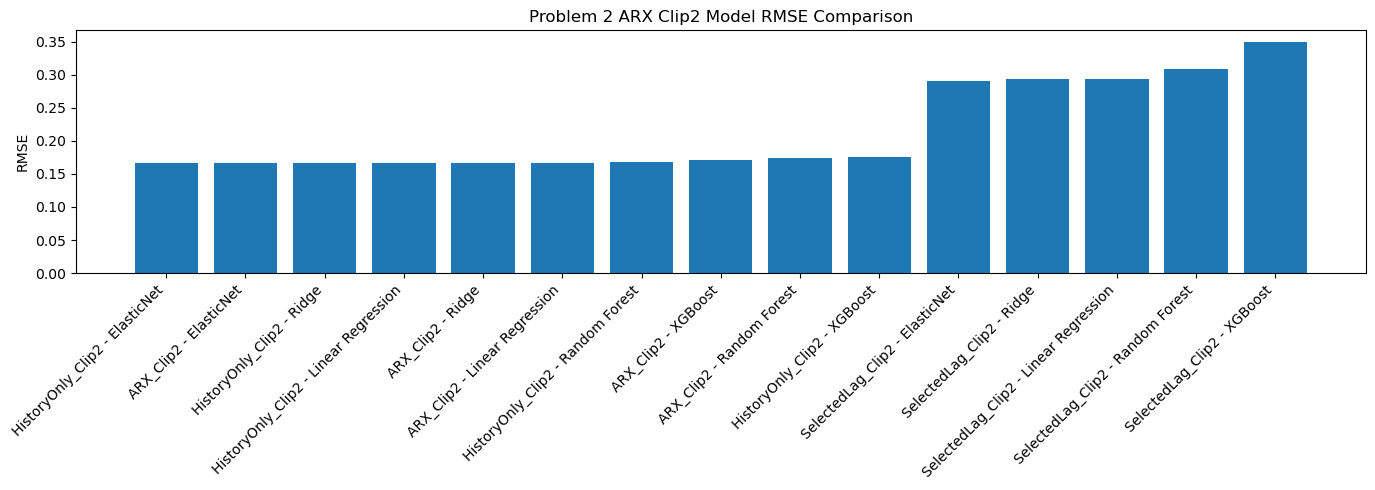

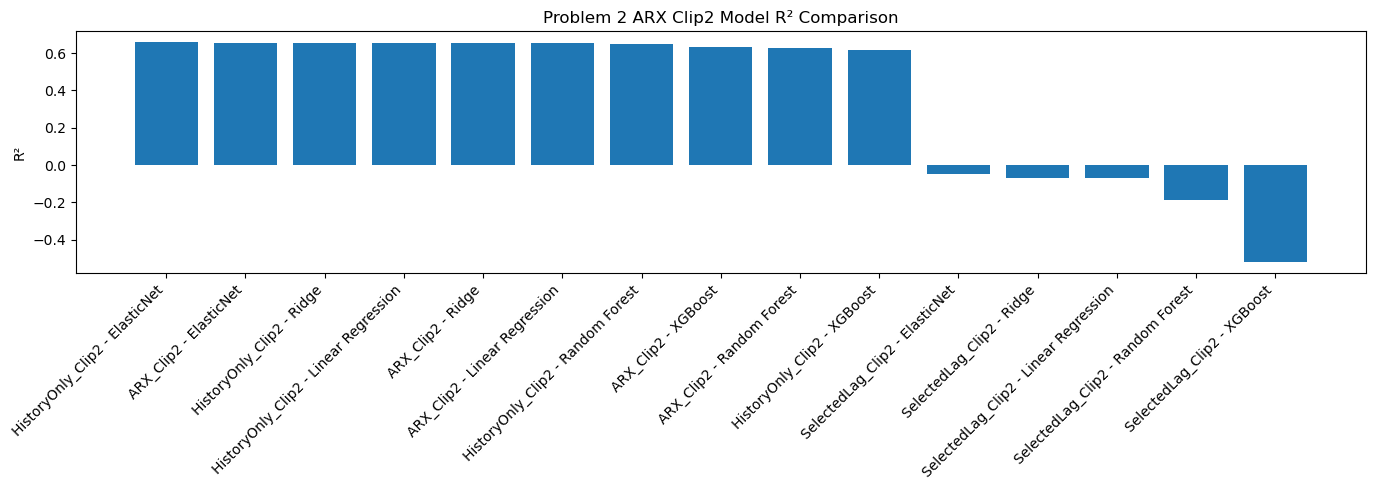

RMSE 图已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_arx_clip2\figures\problem2_arx_clip2_rmse_comparison.png
R² 图已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_arx_clip2\figures\problem2_arx_clip2_r2_comparison.png


In [15]:
plot_df = results_df.copy()
plot_df["label"] = plot_df["feature_set"] + " - " + plot_df["model"]

plt.figure(figsize=(14, 5))
plt.bar(plot_df["label"], plot_df["RMSE"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("RMSE")
plt.title("Problem 2 ARX Clip2 Model RMSE Comparison")
plt.tight_layout()

rmse_fig_path = FIG_DIR / "problem2_arx_clip2_rmse_comparison.png"
plt.savefig(rmse_fig_path, dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(14, 5))
plt.bar(plot_df["label"], plot_df["R2"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("R²")
plt.title("Problem 2 ARX Clip2 Model R² Comparison")
plt.tight_layout()

r2_fig_path = FIG_DIR / "problem2_arx_clip2_r2_comparison.png"
plt.savefig(r2_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("RMSE 图已保存：", rmse_fig_path)
print("R² 图已保存：", r2_fig_path)


## 16. 可视化：最佳模型预测曲线和残差图

根据 RMSE 最小选择最佳模型。


最佳模型：


,feature_set,model,n_features,train_samples,test_samples,MAE,RMSE,R2,MAPE_percent
0,HistoryOnly_Clip2,ElasticNet,3,3821,1639,0.044995,0.166093,0.65734,30.255403


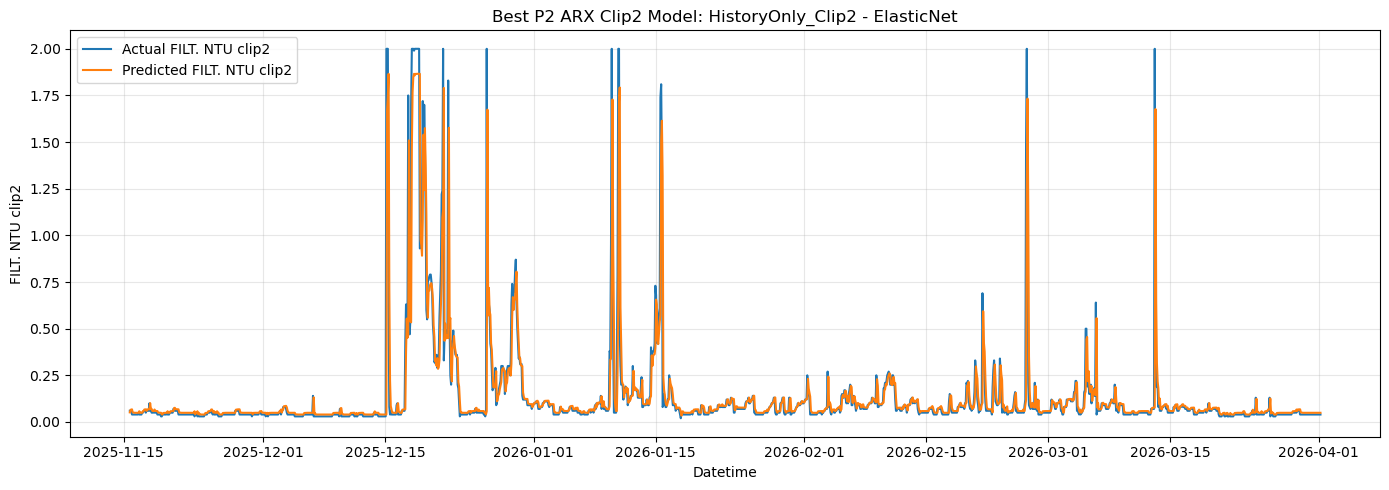

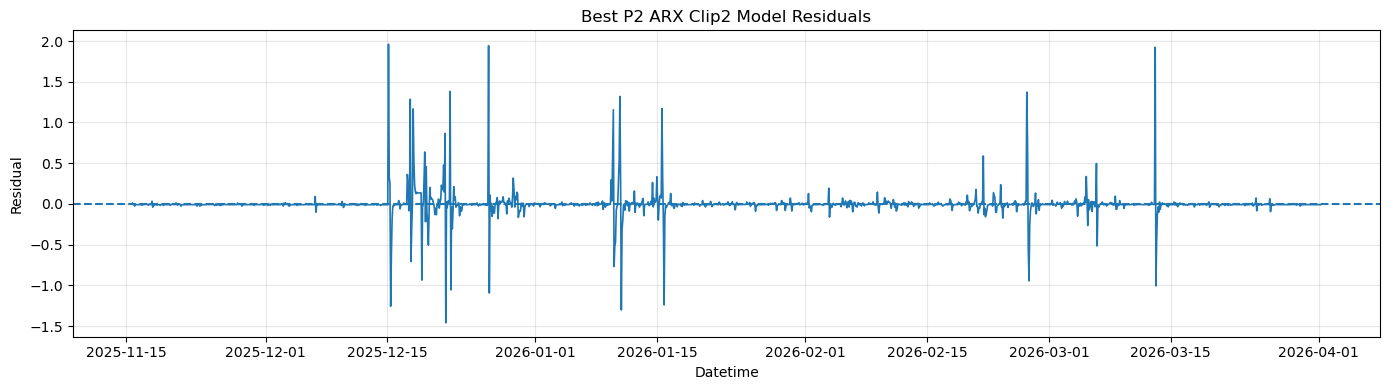

最佳模型预测曲线已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_arx_clip2\figures\problem2_arx_clip2_best_model_timeseries.png
残差图已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_arx_clip2\figures\problem2_arx_clip2_best_model_residuals.png


In [16]:
best_row = results_df.iloc[0]
best_feature_set = best_row["feature_set"]
best_model_name = best_row["model"]

best_pred_df = predictions_df[
    (predictions_df["feature_set"] == best_feature_set) &
    (predictions_df["model"] == best_model_name)
].copy()

print("最佳模型：")
display(best_row.to_frame().T)

plt.figure(figsize=(14, 5))
plt.plot(
    best_pred_df["DATETIME"],
    best_pred_df["target_FILT_NTU_clip2"],
    label="Actual FILT. NTU clip2",
    linewidth=1.5,
)
plt.plot(
    best_pred_df["DATETIME"],
    best_pred_df["predicted_FILT_NTU_clip2"],
    label="Predicted FILT. NTU clip2",
    linewidth=1.5,
)
plt.title(f"Best P2 ARX Clip2 Model: {best_feature_set} - {best_model_name}")
plt.xlabel("Datetime")
plt.ylabel("FILT. NTU clip2")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

best_ts_fig_path = FIG_DIR / "problem2_arx_clip2_best_model_timeseries.png"
plt.savefig(best_ts_fig_path, dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(
    best_pred_df["DATETIME"],
    best_pred_df["residual_clip2"],
    linewidth=1.2,
)
plt.axhline(0, linestyle="--")
plt.title("Best P2 ARX Clip2 Model Residuals")
plt.xlabel("Datetime")
plt.ylabel("Residual")
plt.grid(alpha=0.3)
plt.tight_layout()

residual_fig_path = FIG_DIR / "problem2_arx_clip2_best_model_residuals.png"
plt.savefig(residual_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("最佳模型预测曲线已保存：", best_ts_fig_path)
print("残差图已保存：", residual_fig_path)


## 17. 输出汇总工作簿和最终摘要

输出：

```text
problem2_arx_clip2_summary.xlsx
problem2_arx_clip2_final_summary.xlsx
```


In [17]:
summary_workbook_path = OUTPUT_DIR / "problem2_arx_clip2_summary.xlsx"

with pd.ExcelWriter(summary_workbook_path, engine="openpyxl") as writer:
    clip_audit.to_excel(writer, sheet_name="clip_audit", index=False)
    audit_df.to_excel(writer, sheet_name="data_audit", index=False)
    feature_summary_df.to_excel(writer, sheet_name="feature_summary", index=False)
    selected_lag_df.to_excel(writer, sheet_name="selected_lag", index=False)
    feature_set_df.to_excel(writer, sheet_name="feature_sets", index=False)
    results_df.to_excel(writer, sheet_name="model_results", index=False)
    enhancement_judgement_df.to_excel(writer, sheet_name="enhancement_judgement", index=False)
    coef_df.to_excel(writer, sheet_name="coefficients", index=False)

final_summary = pd.DataFrame([
    {
        "item": "model_family",
        "value": "ARX model with FILT. NTU self-history terms and FILT. NTU clipping at 2",
    },
    {
        "item": "target",
        "value": "FILT. NTU_clip2",
    },
    {
        "item": "clipping_rule",
        "value": f"FILT. NTU_clip2 = min(FILT. NTU, {TARGET_CLIP_UPPER})",
    },
    {
        "item": "self_history_terms",
        "value": ", ".join(target_ar_features),
    },
    {
        "item": "exogenous_variables",
        "value": ", ".join(available_vars),
    },
    {
        "item": "best_feature_set",
        "value": best_feature_set,
    },
    {
        "item": "best_model",
        "value": best_model_name,
    },
    {
        "item": "best_MAE",
        "value": best_row["MAE"],
    },
    {
        "item": "best_RMSE",
        "value": best_row["RMSE"],
    },
    {
        "item": "best_R2",
        "value": best_row["R2"],
    },
    {
        "item": "main_purpose",
        "value": "Test whether adding FILT. NTU self-history and clipping at 2 improves dynamic modeling of filtered water turbidity.",
    },
])

final_summary_path = OUTPUT_DIR / "problem2_arx_clip2_final_summary.xlsx"
final_summary.to_excel(final_summary_path, index=False)

print("汇总工作簿已保存：", summary_workbook_path)
print("最终摘要已保存：", final_summary_path)

display(final_summary)


汇总工作簿已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_arx_clip2\problem2_arx_clip2_summary.xlsx
最终摘要已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_arx_clip2\problem2_arx_clip2_final_summary.xlsx


,item,value
0,model_family,ARX model with FILT. NTU self-history terms an...
1,target,FILT. NTU_clip2
2,clipping_rule,"FILT. NTU_clip2 = min(FILT. NTU, 2.0)"
3,self_history_terms,"FILT. NTU_clip2_lag1, FILT. NTU_clip2_lag2, FI..."
4,exogenous_variables,"R/W NTU, R/W PH, ALUM, F/RIDE, R/W FLOW"
5,best_feature_set,HistoryOnly_Clip2
6,best_model,ElasticNet
7,best_MAE,0.044995
8,best_RMSE,0.166093
9,best_R2,0.65734


## 18. 论文中可使用的说明

可以写：

```text
为刻画滤后水浊度的动态惯性，本文在外生变量 selected-lag 模型基础上引入 FILT. NTU 自身历史项，包括 FILT. NTU_lag1、FILT. NTU_lag2 和 FILT. NTU_lag3，分别对应过去 2、4、6 小时的滤后水浊度。同时，为降低极端浊度值对模型训练的影响，本文将 FILT. NTU 超过 2 的样本截断为 2，得到 FILT. NTU_clip2。随后比较仅外生变量 selected-lag、仅历史项 HistoryOnly 以及自回归外生输入 ARX 三类模型，以检验自历史项和截断处理对模型精度的贡献。
```

英文：

```text
To capture the dynamic inertia of filtered water turbidity, autoregressive terms of FILT. NTU were incorporated into the selected-lag exogenous input model, including FILT. NTU_lag1, FILT. NTU_lag2, and FILT. NTU_lag3, corresponding to the previous 2, 4, and 6 hours. Meanwhile, FILT. NTU values greater than 2 were clipped to 2 to reduce the influence of extreme turbidity observations. The selected-lag, history-only, and ARX models were then compared to evaluate the contribution of self-history terms and clipping.
```


In [18]:
print("=" * 80)
print("问题二 FILT. NTU 自历史项 + 截断到 2 的 ARX 模型已完成。")
print("=" * 80)

print("\n核心输出文件：")
print("1. clipping 审计：", clip_audit_path)
print("2. 数据审计：", audit_path)
print("3. 特征说明：", feature_summary_path)
print("4. selected lag：", selected_lag_path)
print("5. 建模数据：", model_data_path)
print("6. 特征集说明：", feature_sets_path)
print("7. 模型结果：", results_path)
print("8. 测试集预测：", predictions_path)
print("9. enhancement 判断：", enhancement_judgement_path)
print("10. 系数表：", coef_path)
print("11. 汇总工作簿：", summary_workbook_path)
print("12. 最终摘要：", final_summary_path)
print("13. 图片目录：", FIG_DIR)
print("14. 模型目录：", MODEL_DIR)

print("\n模型结果：")
display(results_df)

print("\n三类模型最佳结果：")
display(best_by_set)

print("\n新增机制判断：")
display(enhancement_judgement_df)

print("\n最终摘要：")
display(final_summary)


问题二 FILT. NTU 自历史项 + 截断到 2 的 ARX 模型已完成。

核心输出文件：
1. clipping 审计： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_arx_clip2\problem2_arx_clip2_clip_audit.xlsx
2. 数据审计： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_arx_clip2\problem2_arx_clip2_data_audit.xlsx
3. 特征说明： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_arx_clip2\problem2_arx_clip2_feature_summary.xlsx
4. selected lag： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_arx_clip2\problem2_arx_clip2_selected_lag_summary.xlsx
5. 建模数据： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_arx_clip2\problem2_arx_clip2_model_data.xlsx
6. 特征集说明： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_arx_clip2\problem2_arx_clip2_feature_sets.xlsx
7. 模型结果： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_arx_clip2\problem2_arx_clip2_model_results.xlsx
8. 测试集预测： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_arx_clip2\problem2_arx_clip2_test_predictions.xlsx
9. enhancement 判断： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_arx_clip2\proble

,feature_set,model,n_features,train_samples,test_samples,MAE,RMSE,R2,MAPE_percent
0,HistoryOnly_Clip2,ElasticNet,3,3821,1639,0.044995,0.166093,0.657340,30.255403
1,ARX_Clip2,ElasticNet,8,3821,1639,0.048313,0.166423,0.655977,37.178050
2,HistoryOnly_Clip2,Ridge,3,3821,1639,0.044045,0.166489,0.655705,28.607347
3,HistoryOnly_Clip2,Linear Regression,3,3821,1639,0.044027,0.166499,0.655662,28.581388
4,ARX_Clip2,Ridge,8,3821,1639,0.050063,0.167260,0.652507,40.884165
5,ARX_Clip2,Linear Regression,8,3821,1639,0.050035,0.167268,0.652475,40.842945
6,HistoryOnly_Clip2,Random Forest,3,3821,1639,0.047303,0.168518,0.647260,28.314061
7,ARX_Clip2,XGBoost,8,3821,1639,0.052155,0.171803,0.633375,32.296643
8,ARX_Clip2,Random Forest,8,3821,1639,0.051499,0.173761,0.624972,31.693463
9,HistoryOnly_Clip2,XGBoost,3,3821,1639,0.047159,0.176108,0.614770,26.752002



三类模型最佳结果：


,feature_set,model,n_features,train_samples,test_samples,MAE,RMSE,R2,MAPE_percent
0,ARX_Clip2,ElasticNet,8,3821,1639,0.048313,0.166423,0.655977,37.178050
1,HistoryOnly_Clip2,ElasticNet,3,3821,1639,0.044995,0.166093,0.657340,30.255403
2,SelectedLag_Clip2,ElasticNet,5,3821,1639,0.194957,0.290378,-0.047343,300.678923



新增机制判断：


,comparison,baseline,candidate,baseline_best_model,candidate_best_model,baseline_RMSE,candidate_RMSE,RMSE_improvement,baseline_R2,candidate_R2,R2_improvement,is_improved
0,HistoryOnly_Clip2 vs SelectedLag_Clip2,SelectedLag_Clip2,HistoryOnly_Clip2,ElasticNet,ElasticNet,0.290378,0.166093,0.124285,-0.047343,0.657340,0.704683,True
1,ARX_Clip2 vs HistoryOnly_Clip2,HistoryOnly_Clip2,ARX_Clip2,ElasticNet,ElasticNet,0.166093,0.166423,-0.000330,0.657340,0.655977,-0.001363,False
2,ARX_Clip2 vs SelectedLag_Clip2,SelectedLag_Clip2,ARX_Clip2,ElasticNet,ElasticNet,0.290378,0.166423,0.123955,-0.047343,0.655977,0.703320,True



最终摘要：


,item,value
0,model_family,ARX model with FILT. NTU self-history terms an...
1,target,FILT. NTU_clip2
2,clipping_rule,"FILT. NTU_clip2 = min(FILT. NTU, 2.0)"
3,self_history_terms,"FILT. NTU_clip2_lag1, FILT. NTU_clip2_lag2, FI..."
4,exogenous_variables,"R/W NTU, R/W PH, ALUM, F/RIDE, R/W FLOW"
5,best_feature_set,HistoryOnly_Clip2
6,best_model,ElasticNet
7,best_MAE,0.044995
8,best_RMSE,0.166093
9,best_R2,0.65734
